## Examen Practico - Segundo Parcial

#### 0) Cargar una de las imágenes histológicas

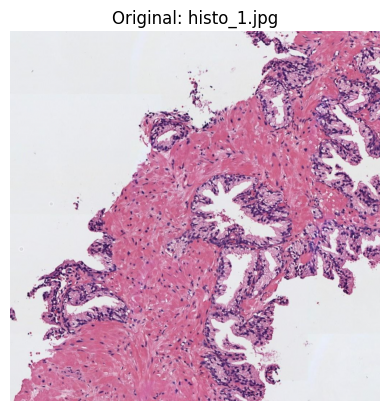

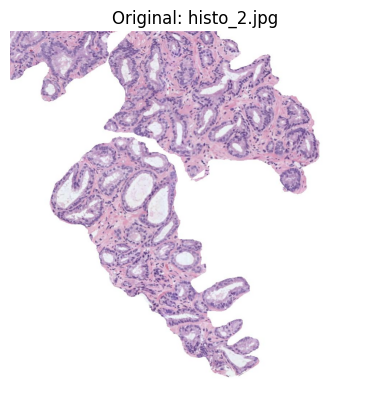

In [3]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float, img_as_ubyte

nombres = ['histo_1.jpg', 'histo_2.jpg']
imagenes_norm = []

for nombre in nombres:
    img = io.imread(nombre)
    img_n = img_as_float(img)
    imagenes_norm.append(img_n)
    
    plt.figure()
    plt.imshow(img_n)
    plt.title(f"Original: {nombre}")
    plt.axis('off')
    plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

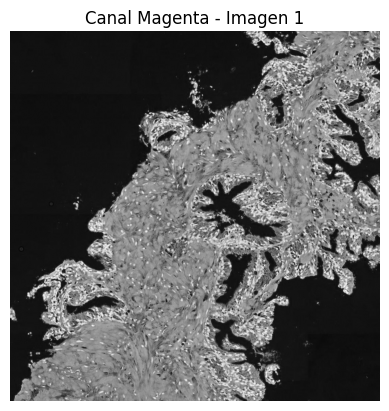

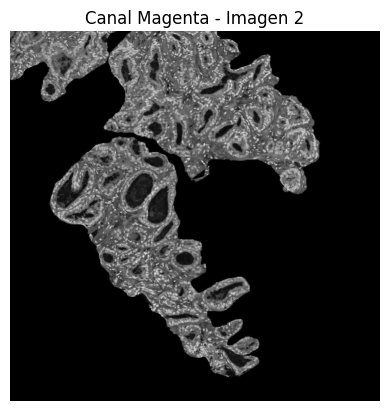

In [4]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta
magentas = []
for i, img in enumerate(imagenes_norm):
    # El magenta es el opuesto al verde en RGB
    mag = 1.0 - img[:,:,1] 
    magentas.append(mag)

# Imagen 1
plt.imshow(magentas[0], cmap='gray')
plt.title("Canal Magenta - Imagen 1")
plt.axis('off')
plt.show()

# Imagen 2
plt.imshow(magentas[1], cmap='gray')
plt.title("Canal Magenta - Imagen 2")
plt.axis('off')
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

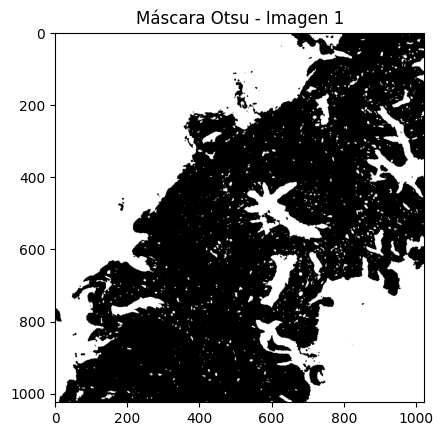

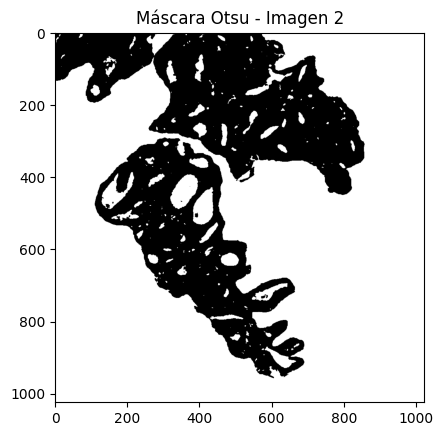

In [5]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

from skimage.filters import threshold_otsu, gaussian

mascaras_otsu = []
for i, mag in enumerate(magentas):
    # Filtro gaussiano 5x5 (sigma aprox 1)
    mag_blur = gaussian(mag, sigma=1)
    
    # Otsu requiere uint8
    mag_u8 = img_as_ubyte(mag_blur)
    thresh = threshold_otsu(mag_u8)
    
    # Lumen/Background = 1, Tejido = 0
    mask = mag_u8 < thresh
    mascaras_otsu.append(mask)
    
    plt.figure()
    plt.imshow(mask, cmap='gray')
    plt.title(f"Máscara Otsu - Imagen {i+1}")
    plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

C:\Users\USER\AppData\Local\Temp\ipykernel_18584\572531960.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(mask, min_size=300)


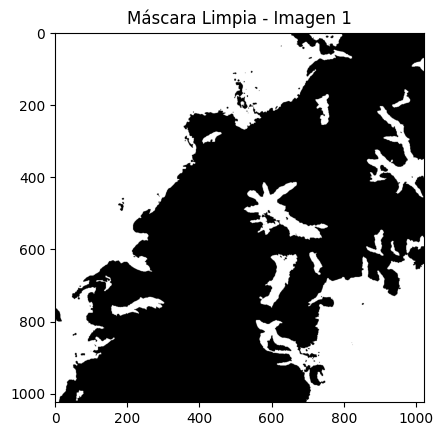

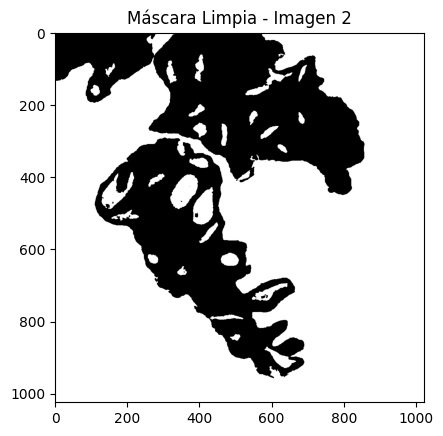

In [6]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

from skimage.morphology import remove_small_objects

mascaras_limpias = []
for i, mask in enumerate(mascaras_otsu):
    clean = remove_small_objects(mask, min_size=300)
    mascaras_limpias.append(clean)
    
    plt.figure()
    plt.imshow(clean, cmap='gray')
    plt.title(f"Máscara Limpia - Imagen {i+1}")
    plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

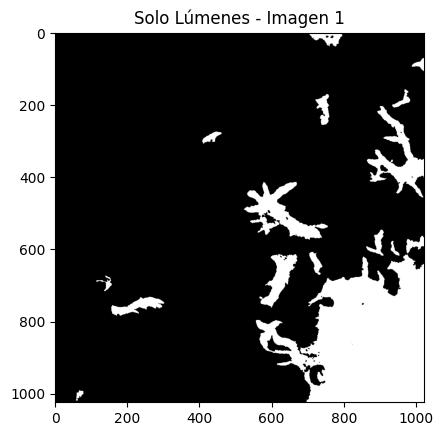

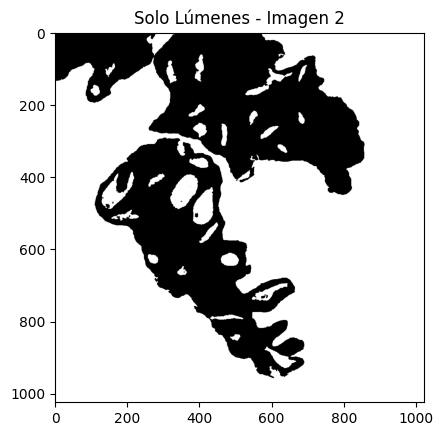

In [7]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

from skimage.segmentation import flood_fill

solo_lumenes = []
for i, mask in enumerate(mascaras_limpias):
    # La semilla (0,0) suele ser el fondo exterior de la placa
    lumen_mask = flood_fill(mask.astype(int), (0, 0), 0)
    solo_lumenes.append(lumen_mask)
    
    plt.figure()
    plt.imshow(lumen_mask, cmap='gray')
    plt.title(f"Solo Lúmenes - Imagen {i+1}")
    plt.show()

#### 5) Rellenar los objetos de los lúmenes

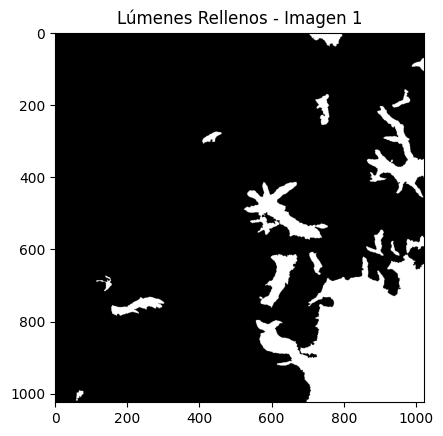

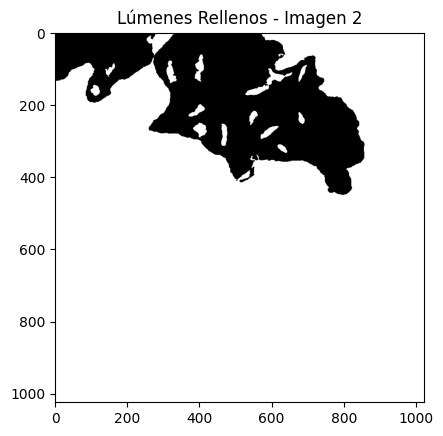

In [8]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

from scipy import ndimage as ndi

lumenes_finales = []
for i, mask in enumerate(solo_lumenes):
    filled = ndi.binary_fill_holes(mask)
    lumenes_finales.append(filled)
    
    plt.figure()
    plt.imshow(filled, cmap='gray')
    plt.title(f"Lúmenes Rellenos - Imagen {i+1}")
    plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

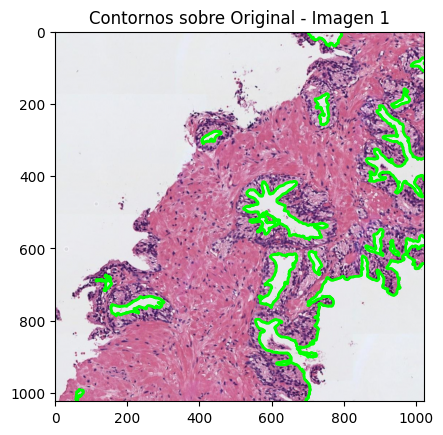

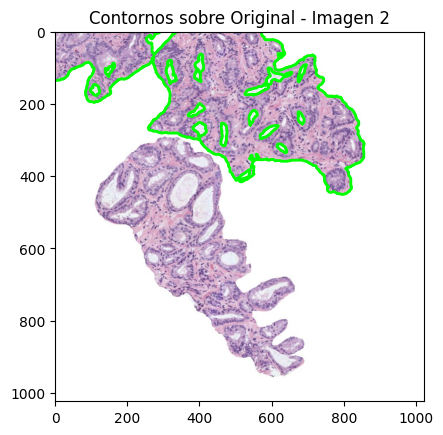

In [9]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

from skimage import measure

for i, mask in enumerate(lumenes_finales):
    contornos = measure.find_contours(mask, 0.5)
    
    plt.figure()
    plt.imshow(imagenes_norm[i])
    for c in contornos:
        plt.plot(c[:, 1], c[:, 0], color='lime', linewidth=2)
    plt.title(f"Contornos sobre Original - Imagen {i+1}")
    plt.show()

#### 7) Identificar y cropear el lumen más grande

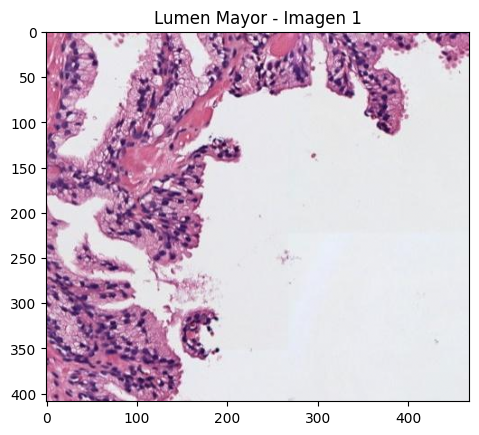

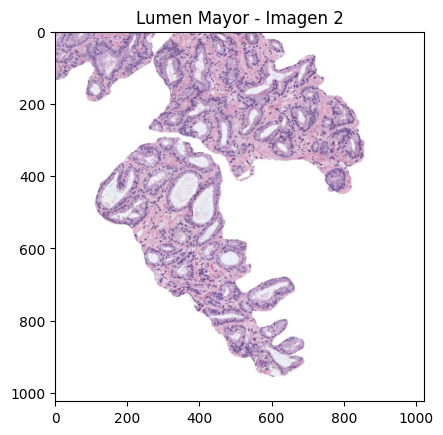

In [10]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

crops = []
props_maximas = []

for i, mask in enumerate(lumenes_finales):
    labels = measure.label(mask)
    props = measure.regionprops(labels)
    
    if props:
        p_max = max(props, key=lambda x: x.area)
        props_maximas.append(p_max)
        
        minr, minc, maxr, maxc = p_max.bbox
        crop = imagenes_norm[i][minr:maxr, minc:maxc]
        crops.append(crop)
        
        plt.figure()
        plt.imshow(crop)
        plt.title(f"Lumen Mayor - Imagen {i+1}")
        plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [11]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

import math

for i, p in enumerate(props_maximas):
    print(f"\n--- Características Imagen {i+1} ---")
    
    # Cálculo de métricas
    res = {
        "1) Área": round(p.area, 4),
        "2) Área BBox": round(p.bbox_area, 4),
        "3) Área Convexa": round(p.convex_area, 4),
        "4) Excentricidad": round(p.eccentricity, 4),
        "5) Diámetro Equiv.": round(p.equivalent_diameter, 4),
        "6) Extensión": round(p.extent, 4),
        "7) Diámetro Feret": round(p.feret_diameter_max, 4),
        "8) Eje Mayor": round(p.major_axis_length, 4),
        "9) Eje Menor": round(p.minor_axis_length, 4),
        "10) Orientación": round(p.orientation, 4),
        "11) Perímetro": round(p.perimeter, 4),
        "12) Solidez": round(p.solidity, 4),
        "13) Compacidad": round((4 * math.pi * p.area) / (p.perimeter**2), 4)
    }
    
    for k, v in res.items():
        print(f"{k}: {v}")


--- Características Imagen 1 ---


C:\Users\USER\AppData\Local\Temp\ipykernel_18584\2741626461.py:24: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  "2) Área BBox": round(p.bbox_area, 4),
C:\Users\USER\AppData\Local\Temp\ipykernel_18584\2741626461.py:25: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  "3) Área Convexa": round(p.convex_area, 4),
C:\Users\USER\AppData\Local\Temp\ipykernel_18584\2741626461.py:27: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  "5) Diámetro Equiv.": round(p.equivalent_diameter, 4),
C:\Users\USER\AppData\Local\Temp\ipykernel_18584\2741626461.py:30: FutureWarning: `RegionProperties.major_axis_length` is deprecated startin

1) Área: 116049.0
2) Área BBox: 191412.0
3) Área Convexa: 149730.0
4) Excentricidad: 0.5155
5) Diámetro Equiv.: 384.3933
6) Extensión: 0.6063
7) Diámetro Feret: 519.2774
8) Eje Mayor: 448.6095
9) Eje Menor: 384.4164
10) Orientación: -1.0336
11) Perímetro: 2768.4287
12) Solidez: 0.7751
13) Compacidad: 0.1903

--- Características Imagen 2 ---
1) Área: 845993.0
2) Área BBox: 1048576.0
3) Área Convexa: 1018370.0
4) Excentricidad: 0.5343
5) Diámetro Equiv.: 1037.8592
6) Extensión: 0.8068
7) Diámetro Feret: 1447.4478
8) Eje Mayor: 1257.8327
9) Eje Menor: 1063.2736
10) Orientación: -1.3228
11) Perímetro: 5997.177
12) Solidez: 0.8307
13) Compacidad: 0.2956
